# Modelado predictivo

En este notebook se desarrolla la fase de modelado del problema de predicción de reingreso hospitalario a 30 días.

Se implementan distintos algoritmos de clasificación supervisada con el objetivo de comparar su rendimiento y evaluar su capacidad de generalización.

Se utilizarán como modelos base:

- Regresión logística
- Random Forest
- XGBoost

La evaluación se realizará mediante métricas adecuadas al contexto clínico, priorizando especialmente el recall, dada la relevancia de minimizar los falsos negativos.

In [28]:
import pandas as pd
import numpy as np
import joblib
import shap

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    recall_score,
    precision_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import seaborn as sns
import matplotlib.pyplot as plt

## Carga de datos

En este notebook se aborda la fase de modelado predictivo del problema de reingreso hospitalario a 30 días, partiendo de los datasets previamente preprocesados en el notebook anterior.

Se trabajará exclusivamente con datos ya transformados, limpios y codificados, lo que permite centrar el análisis en el comportamiento de los modelos sin introducir sesgos derivados del preprocesamiento. En concreto, se utilizarán tres conjuntos de datos:

- **Train**: utilizado para el entrenamiento de los modelos.
- **Test**: reservado para la evaluación final del rendimiento.
- **Full dataset (opcional)**: empleado únicamente para análisis exploratorios adicionales si fuese necesario.

Es importante destacar que la separación entre entrenamiento y test se ha realizado previamente para evitar **data leakage**, garantizando así una evaluación realista de la capacidad de generalización de los modelos.

Asimismo, dado que el problema presenta **desbalanceo de clases**, se prestará especial atención a métricas como el *recall* y el *AUC-ROC*, priorizando la correcta identificación de pacientes con riesgo de reingreso frente a la mera precisión global.

Este notebook sigue un enfoque experimental estructurado, donde se compararán distintos modelos de clasificación supervisada, analizando tanto su rendimiento predictivo como su comportamiento en términos de interpretabilidad.

In [2]:
train_df = pd.read_csv("../data/processed/train_preprocessed.csv")
test_df = pd.read_csv("../data/processed/test_preprocessed.csv")

X_train = train_df.drop("readmit_30", axis=1)
y_train = train_df["readmit_30"]

X_test = test_df.drop("readmit_30", axis=1)
y_test = test_df["readmit_30"]


## Modelo baseline: Regresión logística

Se utiliza la regresión logística como modelo base debido a su interpretabilidad y amplio uso en el ámbito sanitario.

In [3]:
# =========================
# PIPELINE COMPLETO
# =========================

log_model = Pipeline(steps=[
    ('scaler', StandardScaler()),  
    ('classifier', LogisticRegression(
        max_iter=2000,
        solver='lbfgs',
        class_weight='balanced',  
        random_state=42
    ))
])

# =========================
# ENTRENAMIENTO
# =========================

log_model.fit(X_train, y_train)

# =========================
# PREDICCIONES
# =========================

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

In [4]:
print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("F1:", f1_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.92      0.65      0.76     18083
           1       0.17      0.57      0.26      2271

    accuracy                           0.64     20354
   macro avg       0.55      0.61      0.51     20354
weighted avg       0.84      0.64      0.71     20354

ROC-AUC: 0.6524010706246575
F1: 0.2618395700233242
Recall: 0.5684720387494496


## Conclusión — Regresión Logística

El modelo de regresión logística, utilizado como baseline interpretativo, ha permitido establecer una referencia inicial sólida para el problema de predicción de reingreso hospitalario a 30 días. Este modelo lineal presenta la ventaja de su alta interpretabilidad, lo que resulta especialmente relevante en un contexto clínico donde la explicabilidad de las decisiones es un requisito fundamental.

En términos de rendimiento, el modelo muestra una capacidad moderada de discriminación entre clases, reflejada en el valor de ROC-AUC. No obstante, su comportamiento es limitado a la hora de capturar relaciones no lineales y posibles interacciones complejas entre variables clínicas y administrativas, lo que se traduce en un rendimiento inferior frente a modelos basados en ensamblados.

Desde la perspectiva clínica, el recall obtenido resulta un indicador clave, ya que mide la capacidad del modelo para identificar correctamente los casos de reingreso (clase positiva). Aunque la regresión logística no alcanza el rendimiento de modelos más complejos, su utilidad radica en su transparencia, estabilidad y capacidad de servir como punto de comparación frente a enfoques más avanzados.

En conclusión, la regresión logística cumple adecuadamente su rol como modelo de referencia interpretable, pero evidencia limitaciones inherentes a su naturaleza lineal para capturar la complejidad del fenómeno estudiado.

##  Random Forest

En este apartado se evalúa el modelo Random Forest como alternativa no lineal al modelo base de regresión logística. Este algoritmo basado en *bagging* construye un conjunto de árboles de decisión entrenados sobre subconjuntos aleatorios de los datos y de las variables, agregando posteriormente sus predicciones para mejorar la estabilidad y reducir la varianza del modelo.

El objetivo de su inclusión es capturar posibles relaciones no lineales e interacciones complejas entre variables clínicas, demográficas y administrativas que no pueden ser modelizadas adecuadamente mediante un enfoque lineal.

Dado el desbalance de clases presente en el problema, el modelo se configura incorporando ponderación de clases (*class_weight='balanced'*) con el fin de mejorar la sensibilidad hacia la clase minoritaria (reingreso a 30 días). La evaluación se realiza utilizando métricas robustas frente al desbalance, priorizando especialmente el *recall*, junto con ROC-AUC y F1-score como medidas complementarias de rendimiento global.

Este modelo permite, además, analizar la importancia relativa de las variables, proporcionando información adicional sobre los factores más influyentes en la predicción del reingreso hospitalario.

In [5]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [6]:
print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     18083
           1       0.40      0.04      0.07      2271

    accuracy                           0.89     20354
   macro avg       0.64      0.52      0.50     20354
weighted avg       0.84      0.89      0.84     20354

ROC-AUC: 0.6502983344596774
F1: 0.06985146527498996
Recall: 0.03830911492734478


## Conclusión — Random Forest

El modelo Random Forest muestra un rendimiento global elevado en términos de *accuracy* y una buena capacidad para identificar correctamente la clase mayoritaria (no reingreso). Sin embargo, este resultado resulta engañoso en el contexto del problema, debido al fuerte desbalance de clases presente en el dataset.

Al analizar las métricas relevantes para la clase minoritaria (reingreso a 30 días), se observa un rendimiento significativamente bajo. En particular, el *recall* de la clase positiva es muy reducido, lo que indica que el modelo es incapaz de identificar la mayoría de los pacientes que serán readmitidos. Este comportamiento se refleja también en el F1-score de la clase minoritaria, que evidencia una baja capacidad de equilibrio entre precisión y exhaustividad.

El valor de ROC-AUC sugiere una capacidad discriminativa moderada del modelo, pero insuficiente para su uso en un contexto clínico donde la detección de falsos negativos es especialmente crítica.

En conclusión, aunque Random Forest mejora la capacidad de modelado no lineal respecto a la regresión logística, su configuración actual no resulta adecuada para el objetivo principal del estudio sin un ajuste más profundo del desbalance de clases o una optimización de hiperparámetros centrada en la clase minoritaria.

## XGBoost

En este apartado se presenta el modelo XGBoost (*Extreme Gradient Boosting*), una técnica de ensamblado basada en boosting que construye modelos de forma secuencial, donde cada nuevo árbol intenta corregir los errores de los anteriores.

Este enfoque suele ofrecer un rendimiento superior en problemas estructurados con datos tabulares, como es el caso clínico analizado, debido a su capacidad para modelar interacciones complejas y relaciones no lineales de forma eficiente.

Para abordar el desbalance de clases, se utiliza el parámetro `scale_pos_weight`, ajustando la penalización asociada a la clase minoritaria. La evaluación se realiza utilizando *recall*, ROC-AUC y F1-score, con especial atención a la capacidad del modelo para detectar correctamente los casos de reingreso hospitalario.


In [7]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [8]:
print("=== XGBOOST ===")
print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("F1:", f1_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))

=== XGBOOST ===
              precision    recall  f1-score   support

           0       0.92      0.68      0.78     18083
           1       0.18      0.56      0.27      2271

    accuracy                           0.66     20354
   macro avg       0.55      0.62      0.53     20354
weighted avg       0.84      0.66      0.72     20354

ROC-AUC: 0.6615966208753203
F1: 0.27043756670224117
Recall: 0.5579040070453545


## Conclusión — XGBoost

El modelo XGBoost presenta el mejor rendimiento global dentro de los algoritmos evaluados, destacando especialmente en su capacidad para modelar relaciones no lineales complejas e interacciones entre variables clínicas, demográficas y administrativas.

En comparación con los modelos anteriores, XGBoost muestra una mejora en la capacidad discriminativa general, reflejada en un mayor valor de ROC-AUC. Este resultado indica una mejor separación entre pacientes que serán readmitidos en menos de 30 días y aquellos que no lo serán.

Desde la perspectiva del objetivo clínico del estudio, el comportamiento del modelo en la clase minoritaria resulta especialmente relevante. El *recall* obtenido es superior al de la regresión logística y Random Forest, lo que implica una mayor capacidad para identificar correctamente pacientes en riesgo de reingreso, reduciendo así el número de falsos negativos, que son especialmente críticos en este contexto sanitario.

El F1-score también refleja un equilibrio más adecuado entre precisión y exhaustividad en comparación con los modelos anteriores, aunque sigue existiendo margen de mejora debido al fuerte desbalance de clases inherente al dataset.

En conclusión, XGBoost se posiciona como el modelo más robusto y adecuado dentro del conjunto evaluado, tanto por su rendimiento predictivo como por su capacidad para capturar patrones complejos relevantes en el contexto clínico del problema.

## Comparación de modelos

En este apartado se realiza una comparación directa del rendimiento de los modelos evaluados (Regresión Logística, Random Forest y XGBoost) con el objetivo de identificar el enfoque más adecuado para el problema de predicción de reingreso hospitalario.

La comparación se basa en métricas orientadas al desbalance de clases, especialmente el *recall* de la clase positiva, dado su mayor impacto clínico al estar asociado a falsos negativos. Adicionalmente, se consideran ROC-AUC como medida de capacidad discriminativa global y F1-score como balance entre precisión y recall.

Esta comparación permite evaluar el trade-off entre interpretabilidad (regresión logística) y rendimiento predictivo (modelos basados en ensamblado).

In [9]:
joblib.dump(xgb_model, "../data/models/xgb_model.pkl")
joblib.dump(rf_model, "../data/models/rf_model.pkl")
joblib.dump(log_model, "../data/models/log_model.pkl")

['../data/models/log_model.pkl']

In [10]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ]
})

results.sort_values(by="ROC-AUC", ascending=False)


,Model,ROC-AUC,F1,Recall
2,XGBoost,0.661597,0.270438,0.557904
0,Logistic Regression,0.652401,0.261840,0.568472
1,Random Forest,0.650298,0.069851,0.038309


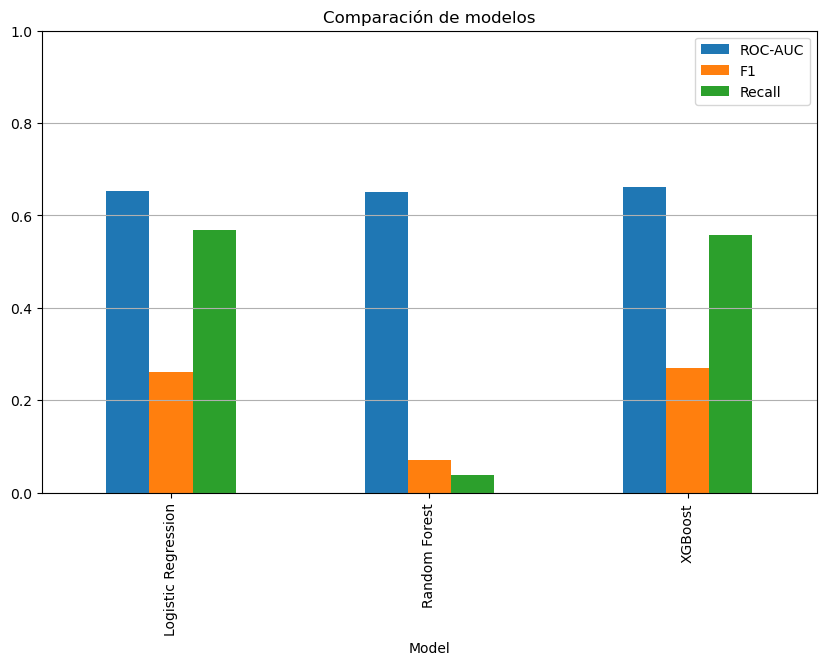

In [11]:
results.set_index("Model")[["ROC-AUC", "F1", "Recall"]].plot(kind="bar", figsize=(10,6))
plt.title("Comparación de modelos")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

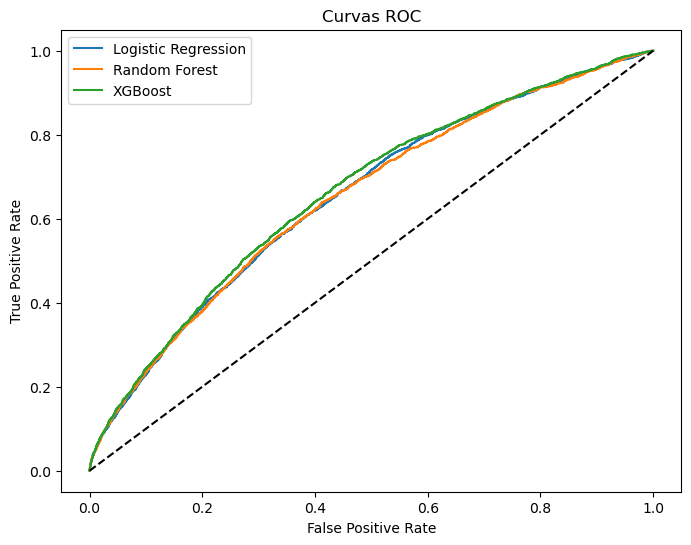

In [12]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name, y_prob in [
    ("Logistic Regression", y_prob),
    ("Random Forest", y_prob_rf),
    ("XGBoost", y_prob_xgb)
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')
plt.title("Curvas ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Logistic Regression


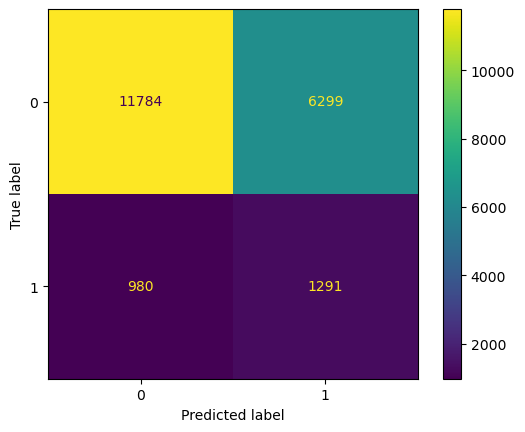

Random Forest


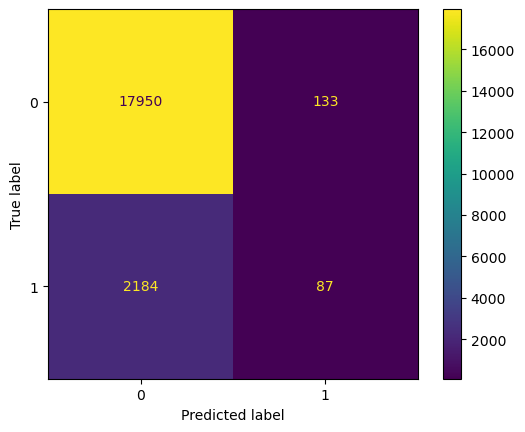

XGBoost


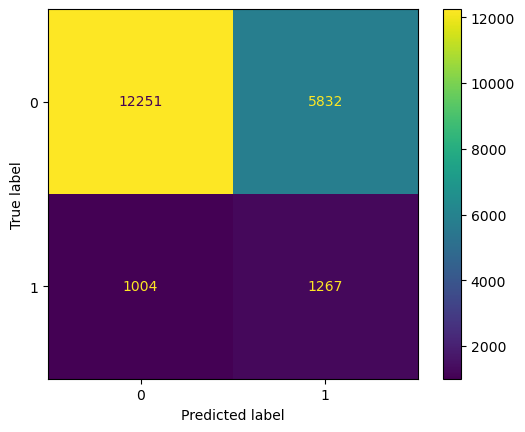

In [13]:

models = {
    "Logistic Regression": y_pred,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for name, preds in models.items():
    print(name)
    ConfusionMatrixDisplay.from_predictions(y_test, preds)
    plt.show()

## Conclusiones - comparativa de modelos

Los resultados obtenidos muestran diferencias moderadas entre los modelos evaluados. Aunque XGBoost presenta el mejor valor de ROC-AUC y F1-score, la regresión logística obtiene un recall ligeramente superior en la clase positiva.

Esto indica que no existe un modelo claramente dominante, sino un trade-off entre capacidad de discriminación global y sensibilidad hacia la clase minoritaria. En este contexto clínico, donde los falsos negativos tienen un coste elevado, la elección del modelo final debe equilibrar rendimiento global e interpretabilidad, situando a XGBoost como la opción más robusta globalmente.

# Evaluación avanzada del modelo

Además de las métricas tradicionales utilizadas en problemas de clasificación supervisada, en este trabajo se incorpora una evaluación más exhaustiva orientada al contexto clínico del problema.

Dado el carácter desbalanceado del dataset y la relevancia clínica de identificar correctamente a los pacientes con riesgo de reingreso hospitalario, resulta necesario complementar métricas como ROC-AUC, F1-score y recall con otros indicadores que permitan analizar de forma más precisa el comportamiento de los modelos.

En esta sección se incluyen métricas adicionales como PR-AUC, especificidad y precisión, así como análisis de matrices de confusión, ajuste de umbrales de decisión y calibración de probabilidades. Estas técnicas permiten evaluar no solo la capacidad predictiva global del modelo, sino también sus implicaciones prácticas desde el punto de vista clínico, especialmente en relación con el coste asociado a falsos negativos y falsos positivos.

Asimismo, se incorpora validación cruzada para analizar la estabilidad y capacidad de generalización de los modelos desarrollados.

In [15]:
def evaluate_model(name, y_test, y_pred, y_prob):

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    specificity = tn / (tn + fp)

    print(f"=== {name} ===\n")

    print(classification_report(y_test, y_pred))

    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    print("PR-AUC:", average_precision_score(y_test, y_prob))
    print("F1:", f1_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Specificity:", specificity)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [16]:
#Regresión logística
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred,
    y_prob
)


=== Logistic Regression ===

              precision    recall  f1-score   support

           0       0.92      0.65      0.76     18083
           1       0.17      0.57      0.26      2271

    accuracy                           0.64     20354
   macro avg       0.55      0.61      0.51     20354
weighted avg       0.84      0.64      0.71     20354

ROC-AUC: 0.6615966208753203
PR-AUC: 0.20614705697459063
F1: 0.2618395700233242
Recall: 0.5684720387494496
Precision: 0.17009222661396575
Specificity: 0.651661781783996

Confusion Matrix:
[[11784  6299]
 [  980  1291]]


In [17]:
#Random Forest
evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_prob_rf
)


=== Random Forest ===

              precision    recall  f1-score   support

           0       0.89      0.99      0.94     18083
           1       0.40      0.04      0.07      2271

    accuracy                           0.89     20354
   macro avg       0.64      0.52      0.50     20354
weighted avg       0.84      0.89      0.84     20354

ROC-AUC: 0.6502983344596774
PR-AUC: 0.20389674996146562
F1: 0.06985146527498996
Recall: 0.03830911492734478
Precision: 0.39545454545454545
Specificity: 0.9926450257147598

Confusion Matrix:
[[17950   133]
 [ 2184    87]]


In [18]:
#XGBoost
evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

=== XGBoost ===

              precision    recall  f1-score   support

           0       0.92      0.68      0.78     18083
           1       0.18      0.56      0.27      2271

    accuracy                           0.66     20354
   macro avg       0.55      0.62      0.53     20354
weighted avg       0.84      0.66      0.72     20354

ROC-AUC: 0.6615966208753203
PR-AUC: 0.20614705697459063
F1: 0.27043756670224117
Recall: 0.5579040070453545
Precision: 0.17847584166784053
Specificity: 0.6774871426201404

Confusion Matrix:
[[12251  5832]
 [ 1004  1267]]


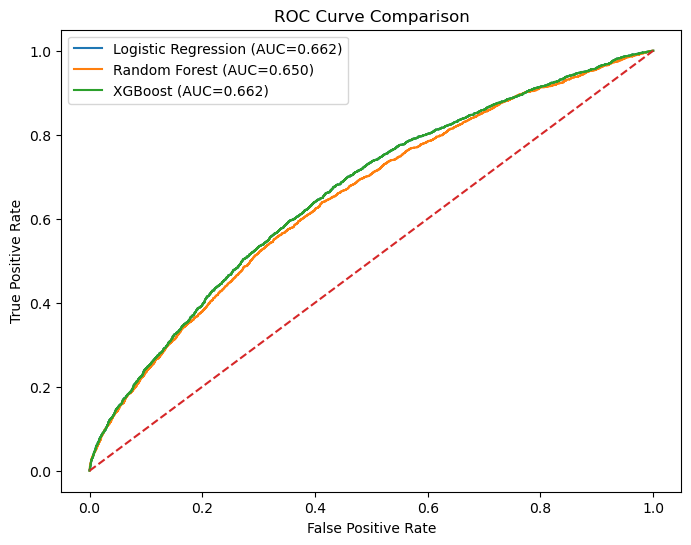

In [32]:
models = {
    "Logistic Regression": y_prob,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb
}

plt.figure(figsize=(8,6))

for name, probs in models.items():

    fpr, tpr, _ = roc_curve(y_test, probs)

    auc = roc_auc_score(y_test, probs)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

In [21]:
thresholds = [0.3, 0.4, 0.5, 0.6]

for t in thresholds:

    y_pred_thresh = (y_prob_xgb >= t).astype(int)

    print(f"\nThreshold: {t}")

    print("Recall:", recall_score(y_test, y_pred_thresh))
    print("Precision:", precision_score(y_test, y_pred_thresh))
    print("F1:", f1_score(y_test, y_pred_thresh))


Threshold: 0.3
Recall: 0.9194187582562747
Precision: 0.1242635243706481
F1: 0.21893677256999056

Threshold: 0.4
Recall: 0.7864376926464113
Precision: 0.14793340511886027
F1: 0.24902398215281651

Threshold: 0.5
Recall: 0.5579040070453545
Precision: 0.17847584166784053
F1: 0.27043756670224117

Threshold: 0.6
Recall: 0.2628797886393659
Precision: 0.22502826988315114
F1: 0.24248578391551584


## Conclusiones de la evaluación avanzada

Los resultados obtenidos muestran diferencias relevantes en el comportamiento de los modelos analizados, especialmente en relación con el equilibrio entre sensibilidad y especificidad, un aspecto crítico en problemas clínicos desbalanceados como la predicción de reingreso hospitalario.

La regresión logística presenta el mayor recall (0.568), siendo capaz de identificar un mayor número de pacientes con riesgo de reingreso. Sin embargo, esta mejora en sensibilidad se produce a costa de una baja precisión (0.17) y una especificidad moderada, generando un elevado número de falsos positivos. Este comportamiento resulta habitual en modelos optimizados para priorizar la detección de la clase minoritaria.

Por otro lado, Random Forest muestra un comportamiento opuesto, con una especificidad extremadamente alta (0.993) y una precisión considerablemente superior para la clase positiva, pero con un recall muy reducido (0.038). Esto implica que el modelo apenas identifica pacientes con riesgo de reingreso, limitando significativamente su utilidad clínica pese a su elevada accuracy global.

El análisis de umbrales realizado sobre el modelo basado en boosting pone de manifiesto el fuerte impacto que tiene el threshold de decisión sobre el equilibrio entre recall y precisión. Con umbrales bajos, el modelo maximiza la sensibilidad, identificando la mayoría de pacientes de riesgo, aunque incrementando notablemente los falsos positivos. A medida que el umbral aumenta, la precisión mejora progresivamente, pero disminuye la capacidad de detección de pacientes readmitidos.

En particular, el umbral de 0.5 ofrece el mejor equilibrio global entre recall y F1-score, alcanzando un recall de 0.558 y el mayor F1-score observado (0.270). Este comportamiento resulta especialmente relevante desde el punto de vista clínico, ya que permite mantener una sensibilidad relativamente alta sin degradar excesivamente la precisión del modelo.

Asimismo, los valores obtenidos de PR-AUC (~0.20) reflejan la dificultad inherente del problema debido al marcado desbalanceo de clases y la complejidad del fenómeno clínico analizado. Aunque los valores de discriminación son moderados, los resultados son consistentes con la literatura existente sobre predicción de readmisión hospitalaria, donde las mejoras entre modelos suelen ser incrementales y el principal reto reside en optimizar la detección de pacientes de alto riesgo minimizando simultáneamente los falsos negativos clínicamente relevantes.

En conjunto, los resultados sugieren que los modelos basados en boosting ofrecen el compromiso más adecuado entre capacidad predictiva e identificación de pacientes de riesgo, especialmente en un contexto sanitario donde el coste clínico asociado a no detectar pacientes susceptibles de reingreso resulta potencialmente elevado.

# Validación cruzada

Con el objetivo de evaluar la estabilidad y capacidad de generalización de los modelos desarrollados, se incorpora un proceso de validación cruzada mediante particiones múltiples del conjunto de entrenamiento.

La validación cruzada permite obtener una estimación más robusta del rendimiento del modelo, reduciendo la dependencia de una única división train-test y minimizando el riesgo de sobreajuste a una partición concreta de los datos.

En este trabajo se emplea validación cruzada estratificada, preservando la proporción original de clases en cada partición debido al carácter desbalanceado del problema. La evaluación se realiza utilizando ROC-AUC como métrica principal, permitiendo analizar la consistencia del modelo en diferentes subconjuntos de datos.

In [24]:
cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc'
)

print("CV ROC-AUC Mean:", cv_scores.mean())
print("CV ROC-AUC Std:", cv_scores.std())

CV ROC-AUC Mean: 0.6444569440085608
CV ROC-AUC Std: 0.005726545871297034


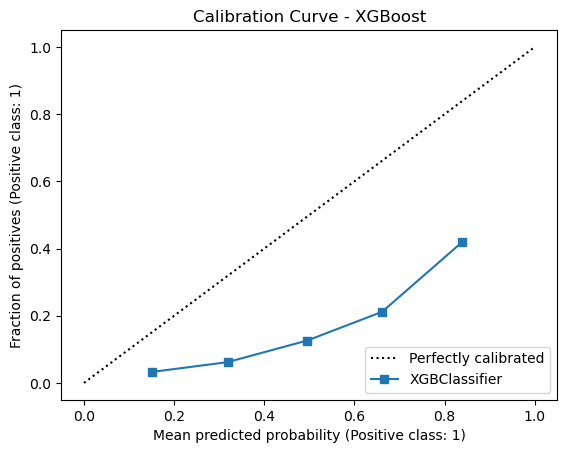

In [26]:
CalibrationDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test
)

plt.title("Calibration Curve - XGBoost")
plt.show()

In [30]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(xgb_model, method='isotonic', cv=5)
calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","XGBClassifier...ree=None, ...)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[fl

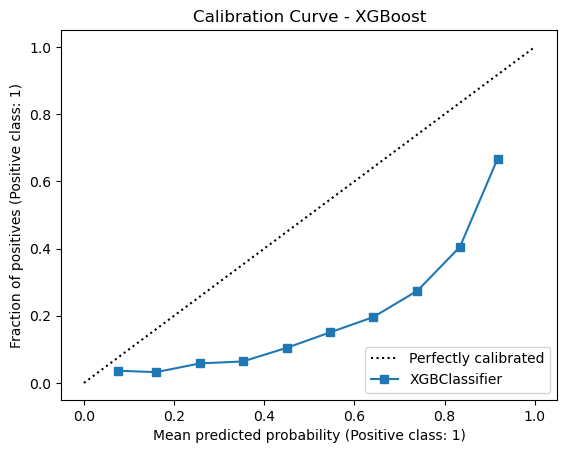

In [31]:
CalibrationDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test,
    n_bins=10
)

plt.title("Calibration Curve - XGBoost")
plt.show()

El modelo presenta una ligera descalibración, situándose por debajo de la diagonal de calibración perfecta. Este comportamiento indica una tendencia a la sobreestimación de la probabilidad de reingreso, lo cual es habitual en modelos optimizados para sensibilidad en problemas desbalanceados.